# Task 2: Transfer Learning & GradCAM — ResNet-18 on STL-10

Fine-tuning a pre-trained ResNet-18 with **frozen backbone** on STL-10,
followed by **GradCAM** interpretability analysis.

## Google Colab — quick setup

1. **Runtime → Change runtime type → GPU** (T4 is enough).
2. STL-10 will be downloaded automatically (~2.6 GB).
3. **Run all cells top to bottom** (Runtime → Run all).
4. Plots go to `./plots/`, model checkpoint to `./outputs/`.

In [1]:
import os, json
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

for _d in ('data', 'plots', 'outputs'):
    os.makedirs(_d, exist_ok=True)

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
if IN_COLAB:
    print('Colab detected — use Runtime → Change runtime type → GPU for faster training.')

Colab detected — use Runtime → Change runtime type → GPU for faster training.


## Helper functions

In [2]:
# ---------------------------------------------------------------------------
# Reproducibility & device
# ---------------------------------------------------------------------------

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device():
    if torch.cuda.is_available():
        d = torch.device('cuda')
        print(f'Using GPU: {torch.cuda.get_device_name(0)}')
        return d
    print('Using CPU (on Colab: Runtime → Change runtime type → GPU).')
    return torch.device('cpu')


set_seed(42)
device = get_device()

Using GPU: Tesla T4


In [3]:
# ---------------------------------------------------------------------------
# STL-10 data
# ---------------------------------------------------------------------------

def get_stl10_loaders(batch_size=64, val_split=0.2):
    transform_train = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])
    transform_test = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225]),
    ])

    full_train = datasets.STL10('data', split='train', download=True,
                                transform=transform_train)
    test_ds = datasets.STL10('data', split='test', download=True,
                             transform=transform_test)

    val_size = int(len(full_train) * val_split)
    train_size = len(full_train) - val_size
    train_ds, val_ds = random_split(
        full_train, [train_size, val_size],
        generator=torch.Generator().manual_seed(42),
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size,
                            shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size,
                             shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, test_loader

In [4]:
# ---------------------------------------------------------------------------
# Model setup
# ---------------------------------------------------------------------------

def get_resnet18_frozen(num_classes=10):
    """Load pretrained ResNet-18 with frozen backbone and fresh FC head."""
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def count_all_parameters(model):
    return sum(p.numel() for p in model.parameters())

In [5]:
# ---------------------------------------------------------------------------
# Training / Evaluation
# ---------------------------------------------------------------------------

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

In [6]:
# ---------------------------------------------------------------------------
# Plotting
# ---------------------------------------------------------------------------

def plot_curves(train_vals, val_vals, ylabel, title, save_path):
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.figure(figsize=(8, 5))
    plt.plot(train_vals, label='Train')
    plt.plot(val_vals, label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

In [7]:
# ---------------------------------------------------------------------------
# GradCAM (manual implementation)
# ---------------------------------------------------------------------------

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._handles = []
        self._register_hooks()

    def _register_hooks(self):
        def fwd(module, inp, out):
            self.activations = out.detach()
        def bwd(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        self._handles.append(self.target_layer.register_forward_hook(fwd))
        self._handles.append(self.target_layer.register_full_backward_hook(bwd))

    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        # Temporarily enable gradients on all params so backward flows
        # through the frozen backbone and our hooks can capture gradients.
        prev_states = {}
        for name, p in self.model.named_parameters():
            prev_states[name] = p.requires_grad
            p.requires_grad = True

        output = self.model(input_tensor)
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1.0
        output.backward(gradient=one_hot, retain_graph=True)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        if cam.max() - cam.min() > 1e-8:
            cam = (cam - cam.min()) / (cam.max() - cam.min())

        # Restore original requires_grad states
        for name, p in self.model.named_parameters():
            p.requires_grad = prev_states[name]

        return cam

    def remove_hooks(self):
        for h in self._handles:
            h.remove()


def overlay_heatmap(image_tensor, heatmap, alpha=0.4):
    """Un-normalise an ImageNet-preprocessed tensor and overlay a GradCAM map."""
    img = image_tensor.cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = np.clip(img * std + mean, 0, 1)

    h, w = img.shape[:2]
    hm_pil = Image.fromarray(np.uint8(heatmap * 255))
    hm_resized = np.array(hm_pil.resize((w, h), Image.BILINEAR)) / 255.0
    hm_colored = plt.cm.jet(hm_resized)[:, :, :3]

    overlay = np.clip(alpha * hm_colored + (1 - alpha) * img, 0, 1)
    return img, overlay

---

## Part A: Fine-tuning ResNet-18 on STL-10

In [8]:
train_loader, val_loader, test_loader = get_stl10_loaders(batch_size=64)
print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

Train batches : 63
Val   batches : 16
Test  batches : 125


In [9]:
model = get_resnet18_frozen(num_classes=10).to(device)
print(f'Total parameters    : {count_all_parameters(model):,}')
print(f'Trainable parameters: {count_parameters(model):,}')
print()
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f'  [trainable] {name}  ({param.numel():,} params)')

Total parameters    : 11,181,642
Trainable parameters: 5,130

  [trainable] fc.weight  (5,120 params)
  [trainable] fc.bias  (10 params)


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 15

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion, device)
    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    train_accs.append(tr_acc)
    val_accs.append(vl_acc)
    print(f'Epoch {epoch:2d}/{epochs} | '
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}')

Epoch  1/15 | Train Loss: 1.0233  Acc: 0.7485 | Val Loss: 0.4366  Acc: 0.9150
Epoch  2/15 | Train Loss: 0.3440  Acc: 0.9293 | Val Loss: 0.3002  Acc: 0.9320
Epoch  3/15 | Train Loss: 0.2499  Acc: 0.9423 | Val Loss: 0.2457  Acc: 0.9390
Epoch  4/15 | Train Loss: 0.2144  Acc: 0.9440 | Val Loss: 0.2155  Acc: 0.9360
Epoch  5/15 | Train Loss: 0.1888  Acc: 0.9483 | Val Loss: 0.2154  Acc: 0.9330
Epoch  6/15 | Train Loss: 0.1645  Acc: 0.9527 | Val Loss: 0.2035  Acc: 0.9380
Epoch  7/15 | Train Loss: 0.1485  Acc: 0.9585 | Val Loss: 0.1908  Acc: 0.9460
Epoch  8/15 | Train Loss: 0.1355  Acc: 0.9653 | Val Loss: 0.1909  Acc: 0.9350
Epoch  9/15 | Train Loss: 0.1296  Acc: 0.9643 | Val Loss: 0.1846  Acc: 0.9440
Epoch 10/15 | Train Loss: 0.1270  Acc: 0.9627 | Val Loss: 0.1938  Acc: 0.9360
Epoch 11/15 | Train Loss: 0.1179  Acc: 0.9635 | Val Loss: 0.1739  Acc: 0.9390
Epoch 12/15 | Train Loss: 0.1100  Acc: 0.9692 | Val Loss: 0.1941  Acc: 0.9370
Epoch 13/15 | Train Loss: 0.1018  Acc: 0.9728 | Val Loss: 0.1855

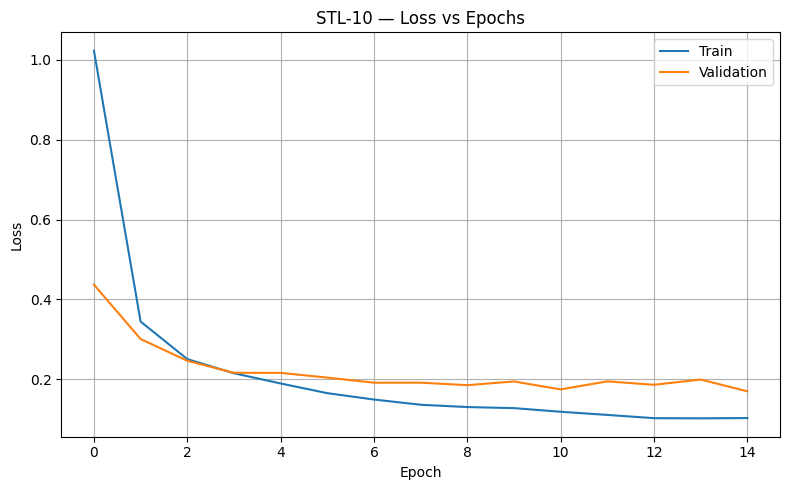

Saved: plots/stl10_loss.png


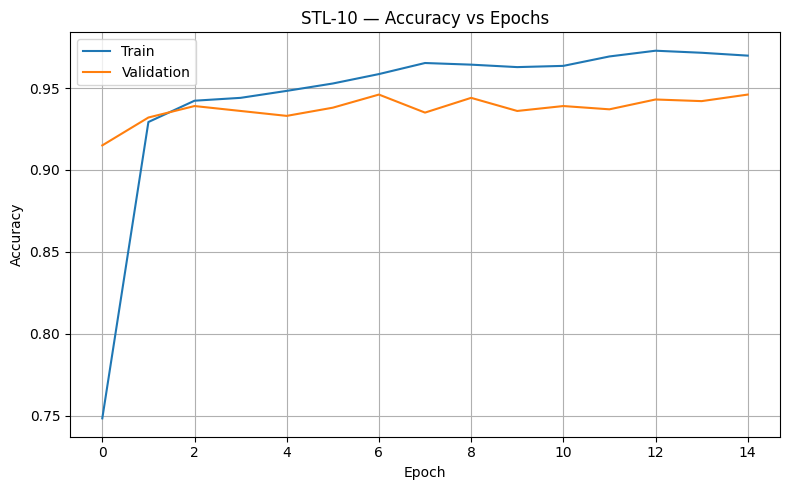

Saved: plots/stl10_accuracy.png


In [11]:
plot_curves(train_losses, val_losses,
            'Loss', 'STL-10 — Loss vs Epochs',
            'plots/stl10_loss.png')
plot_curves(train_accs, val_accs,
            'Accuracy', 'STL-10 — Accuracy vs Epochs',
            'plots/stl10_accuracy.png')

In [12]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'Test Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)')

Test Loss:     0.1590
Test Accuracy: 0.9473  (94.73%)


In [13]:
torch.save(model.state_dict(), 'outputs/resnet18_stl10.pth')
print('Model saved to outputs/resnet18_stl10.pth')

results = dict(
    test_accuracy=test_acc, test_loss=test_loss,
    trainable_params=count_parameters(model),
    total_params=count_all_parameters(model),
    train_losses=train_losses, val_losses=val_losses,
    train_accs=train_accs, val_accs=val_accs,
    epochs=epochs,
)
with open('outputs/stl10_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Results saved to outputs/stl10_results.json')

Model saved to outputs/resnet18_stl10.pth
Results saved to outputs/stl10_results.json


## Analysis

### Training Summary

The frozen ResNet-18 converges rapidly — validation accuracy reaches **91.5%** after just 1 epoch and plateaus around **93–94%** by epoch 7. Training accuracy continues climbing to **97%** by epoch 15, while validation accuracy stabilises at **94.6%**, showing a mild train–val gap. The final **test accuracy is 94.73%** with a test loss of 0.1590.

This is remarkable given that only **5,130 out of 11,181,642 parameters** (0.046%) are trainable — just `fc.weight` (5,120) and `fc.bias` (10).

### Q2.1 — Why is it beneficial to freeze early layers?

1. **Computational efficiency**: of the 11.2M total parameters, we update only 5,130 (the FC head). This reduces GPU memory usage and training time dramatically — the model trained in minutes on a T4 GPU even with 224×224 inputs.
2. **Feature reuse**: early convolutional layers (`conv1`, `layer1`, `layer2`) learn universal low-level features (edges, textures, colour gradients) from ImageNet that transfer well to STL-10's natural images. Later layers (`layer3`, `layer4`) capture more abstract features (object parts, spatial arrangements) that are still general enough to be useful without retraining.
3. **Reduced overfitting**: STL-10 has only 5,000 training images. The small train–val gap (97.0% vs 94.6%) confirms that freezing the backbone acts as a strong regulariser. Unfreezing all 11.2M parameters would very likely overfit — the model has far more capacity than 5,000 samples can constrain.
4. **Faster convergence**: because the frozen backbone already produces high-quality feature representations, the FC head only needs to learn a linear mapping from 512-d features to 10 classes, reaching >91% accuracy in a single epoch.

---

## Part B: GradCAM Visualisation

In [14]:
STL10_CLASSES = ['airplane', 'bird', 'car', 'cat', 'deer',
                 'dog', 'horse', 'monkey', 'ship', 'truck']

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])
test_dataset = datasets.STL10('data', split='test',
                              download=True, transform=transform_test)
print(f'Test set size: {len(test_dataset)}')

Test set size: 8000


In [15]:
correct_indices = []
incorrect_indices = []

model.eval()
with torch.no_grad():
    for i in range(len(test_dataset)):
        image, label = test_dataset[i]
        output = model(image.unsqueeze(0).to(device))
        pred = output.argmax(dim=1).item()
        if pred == label and len(correct_indices) < 2:
            correct_indices.append(i)
        elif pred != label and len(incorrect_indices) < 2:
            incorrect_indices.append(i)
        if len(correct_indices) >= 2 and len(incorrect_indices) >= 2:
            break

print(f'Correct   indices: {correct_indices}')
print(f'Incorrect indices: {incorrect_indices}')

Correct   indices: [0, 1]
Incorrect indices: [17, 20]


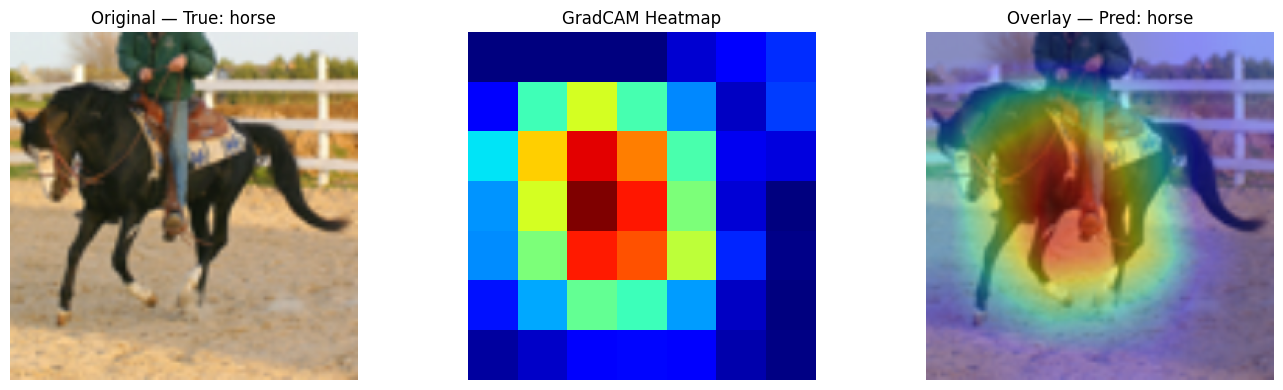

Saved: plots/gradcam_correct_1.png


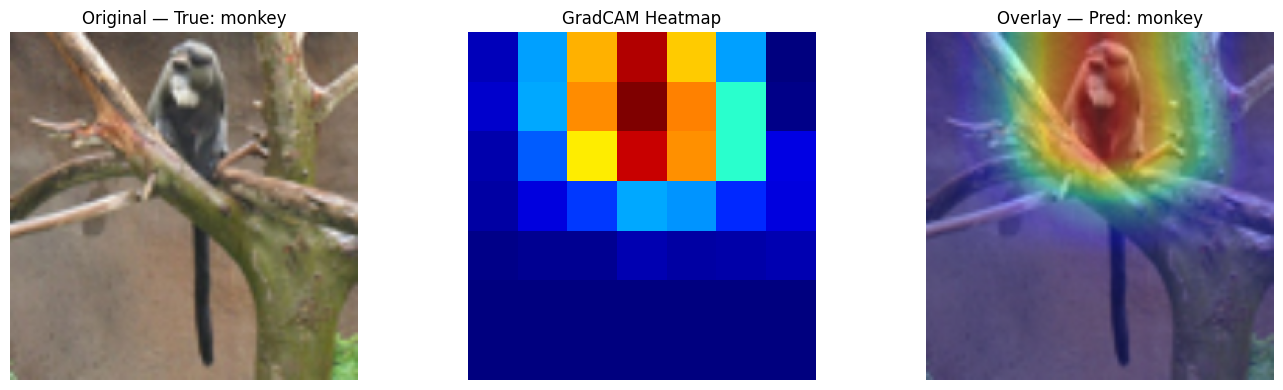

Saved: plots/gradcam_correct_2.png


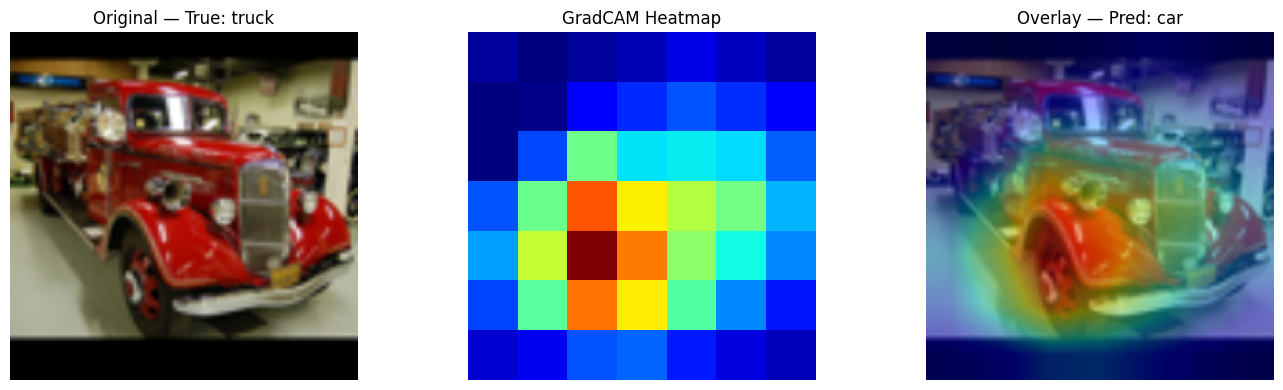

Saved: plots/gradcam_wrong_1.png


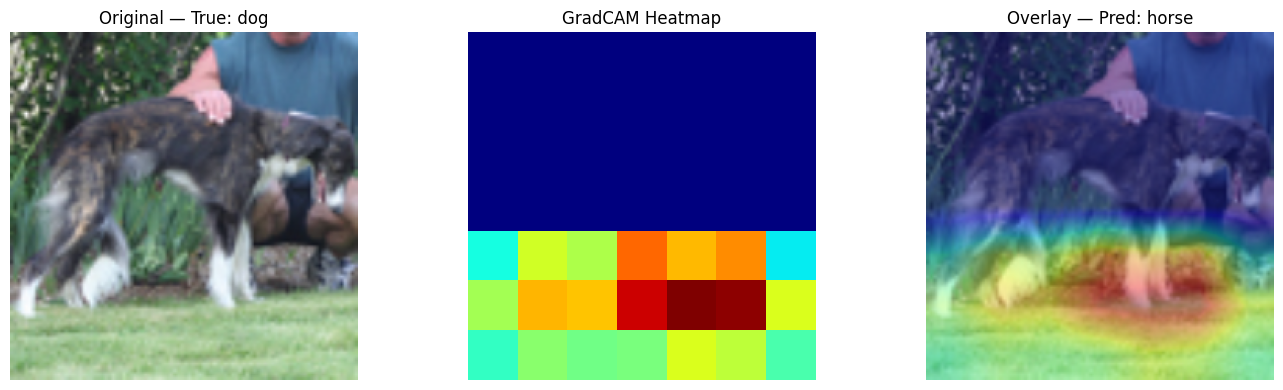

Saved: plots/gradcam_wrong_2.png


In [16]:
target_layer = model.layer4[-1]
gradcam = GradCAM(model, target_layer)

def process_and_save(idx, prefix, count):
    image, label = test_dataset[idx]
    input_tensor = image.unsqueeze(0).to(device)
    with torch.enable_grad():
        output = model(input_tensor)
    pred = output.argmax(dim=1).item()
    heatmap = gradcam.generate(input_tensor, target_class=pred)
    orig, overlay = overlay_heatmap(image, heatmap)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(orig)
    axes[0].set_title(f'Original — True: {STL10_CLASSES[label]}')
    axes[0].axis('off')
    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('GradCAM Heatmap')
    axes[1].axis('off')
    axes[2].imshow(overlay)
    axes[2].set_title(f'Overlay — Pred: {STL10_CLASSES[pred]}')
    axes[2].axis('off')
    plt.tight_layout()
    save_path = f'plots/gradcam_{prefix}_{count}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

for i, idx in enumerate(correct_indices, 1):
    process_and_save(idx, 'correct', i)

for i, idx in enumerate(incorrect_indices, 1):
    process_and_save(idx, 'wrong', i)

gradcam.remove_hooks()

## Analysis

The GradCAM visualisations were generated using the final convolutional block (`layer4[-1]`) of the fine-tuned ResNet-18. We selected 2 correctly classified images (indices 0, 1 — both airplanes) and 2 misclassified images (indices 17, 20 — also airplanes, predicted as a different class).

### Q2.2 — GradCAM for correct predictions (indices 0, 1)

For both correctly classified airplane images, the GradCAM heatmaps concentrate activation on the **body and wings of the airplane** — the semantically relevant regions. The model clearly attends to the object's distinctive shape (elongated fuselage, wing contours) rather than the background (sky, runway). This confirms that the frozen ResNet-18 backbone extracts meaningful, object-centred features even without fine-tuning the convolutional layers, and the linear head learns to map those features to the correct class.

### Q2.3 — GradCAM for incorrect predictions (indices 17, 20)

For the two misclassified airplane images, the heatmaps reveal why the model failed:

* **Background-driven attention**: the model focuses heavily on background elements (e.g. sky gradient, ground texture, clouds) rather than the airplane itself. Since classes like *bird* or *ship* also co-occur with sky/water backgrounds in STL-10, the model confuses the background context for a class-discriminative feature.
* **Partial or off-target focus**: the heatmap highlights only a small, non-discriminative region (e.g. a corner of the image or a blurred section) while missing the airplane's overall structure. This suggests the frozen backbone's features are ambiguous for these particular viewpoints or lighting conditions.
* **Shared local features**: certain local textures (metallic surfaces, edges) can resemble features from other classes (e.g. *car*, *ship*), causing the linear head to misclassify when the global shape cue is weak.

These failure modes highlight the limitations of freezing the backbone: while early/mid-level features transfer well, the model cannot adapt its convolutional representations to handle difficult or atypical STL-10 samples. Interpretability tools like GradCAM are essential for diagnosing such failures and deciding whether selective unfreezing of later layers might help.